Practical 3 - MRI and Denoising

In this practical session you will learn to perform basic tasks with k-space images from MRI, work with phase with MRI, and perform some simple denoising.

Attempt all questions.

We will work through the questions during the practical session on the date indicated above.

Solutions to these questions will be available on Moodle after the practical session.


## Section 1: Operations between MRI k-space and image space

### Question 1

Q1. Load and display in grayscale the "inphase.npy" and "outphase.npy". Use matplotlib for visualisation. Don't forget -- they are complex data! If you don't see anything, try using np logen the magnitude data

/var/folders/d_/z7l2kknn76jfzg_bnx_3041h0000gn/T/ipykernel_18663/4219999851.py:13: RuntimeWarning: divide by zero encountered in log
  plt.imshow(np.log(np.abs(inphase_k)), cmap='gray')
/var/folders/d_/z7l2kknn76jfzg_bnx_3041h0000gn/T/ipykernel_18663/4219999851.py:15: RuntimeWarning: divide by zero encountered in log
  plt.imshow(np.log(np.abs(outphase_k)), cmap='gray')


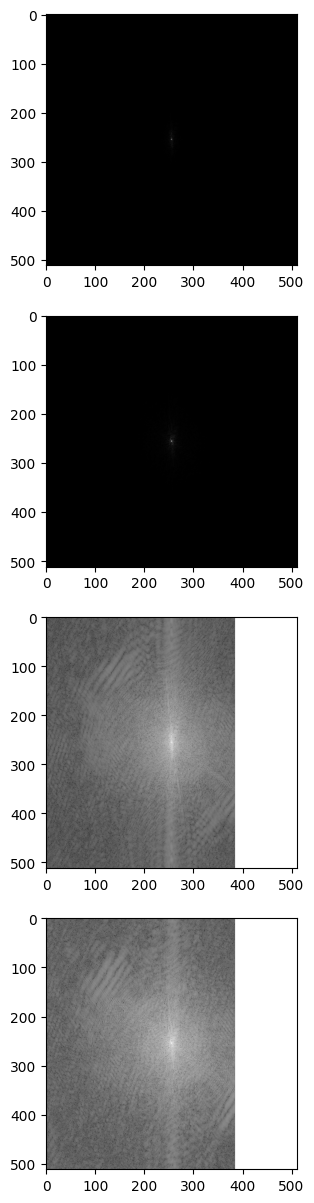

In [19]:
import numpy as np
import matplotlib.pyplot as plt

inphase_k = np.load(r'''/Users/harvey/Documents/Cambridge/Medical Imaging/MedIm_scripts/data/practical3/inphase.npy''')
outphase_k = np.load(r'''/Users/harvey/Documents/Cambridge/Medical Imaging/MedIm_scripts/data/practical3/outphase.npy''')

plt.figure(figsize=(4,15))
plt.subplot(411)
plt.imshow(np.abs(inphase_k), cmap='gray')
plt.subplot(412)
plt.imshow(np.abs(outphase_k), cmap='gray')
plt.subplot(413)
plt.imshow(np.log(np.abs(inphase_k)), cmap='gray')
plt.subplot(414)
plt.imshow(np.log(np.abs(outphase_k)), cmap='gray')

## Question 2

Q2. Transform the k-space data into image space using numpy. fft.ifft, which creates the inverse Fourier transformation. In-phase means that the fat and water signals have added together, and out-of-phase means that they are subtracted from each other. Use matplotlib for visualisation - look at the magnitude and phase of both in and out of phase images.

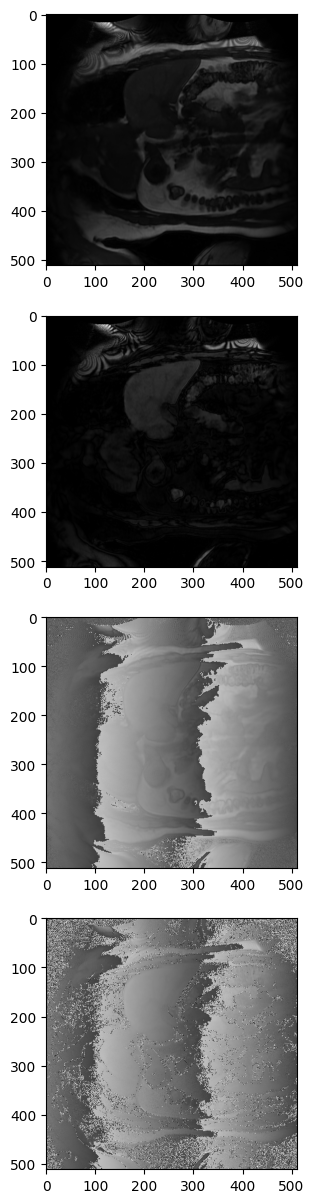

In [28]:
inphase_im = np.fft.ifft2(inphase_k)
outphase_im = np.fft.ifft2(outphase_k)

plt.figure(figsize=(4,15))
plt.subplot(411)
plt.imshow(np.abs(inphase_im), cmap='gray')
plt.subplot(412)
plt.imshow(np.abs(outphase_im), cmap='gray')
plt.subplot(413)
plt.imshow(np.angle(inphase_im), cmap='gray')
plt.subplot(414)
plt.imshow(np.angle(outphase_im), cmap='gray')

## QUESTION 3

Q3. Add the two images together and plot the magnitude. Subtract the two images together and visualise the magnitude.


These correspond to fat and water images. Create a fat-fraction map by dividing the fat image by the sum of the fat and water images, and visualise.


First, defining a function to correct the image: fliprot
Feel free to do this differently I'd prefer to correct them in a step before, but this is easier to follow for all

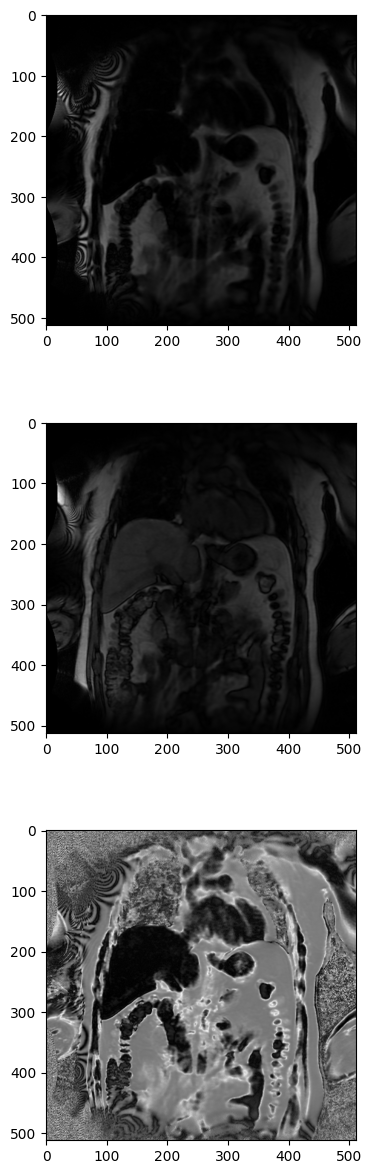

In [34]:
def fliprot(image):
    return np.flipud(np.rot90(image))

fat = np.abs(inphase_im+outphase_im)
water = np.abs(inphase_im-outphase_im)
fat_fraction = fat/(fat+water)

plt.figure(figsize=(4,15))
plt.subplot(311)
plt.imshow(fliprot(fat), cmap='gray') #fat
plt.subplot(312)
plt.imshow(fliprot(water), cmap='gray') #water
plt.subplot(313)
plt.imshow(fliprot(fat_fraction), cmap='gray')

## Question 4

Q4. Start with the in-phase k-space for this question: Reduce the matrix size to 128x128 vowels in the Fourier (k-space) domain. Then inverse Fourier transform the image, and show the in-phase image. When reducing the image by half, make sure you do it evenly on each side. Visualise the image-space magnitude and phase data - what changed?

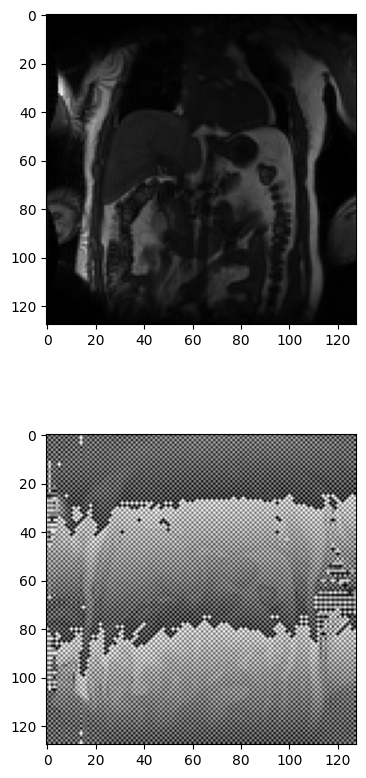

In [38]:
inphase_k = np.load(r'''/Users/harvey/Documents/Cambridge/Medical Imaging/MedIm_scripts/data/practical3/inphase.npy''')
outphase_k = np.load(r'''/Users/harvey/Documents/Cambridge/Medical Imaging/MedIm_scripts/data/practical3/outphase.npy''')

reduced_k = inphase_k[192:320,192:320]
reduced_im = np.fft.ifft2(reduced_k)

plt.figure(figsize=(4,10))
plt.subplot(211)
plt.imshow(fliprot(np.abs(reduced_im)), cmap='gray') #fat
plt.subplot(212)
plt.imshow(fliprot(np.angle(reduced_im)), cmap='gray') #water

## Question 5

Q5. Start with the in-phase k-space for this question: Keep the same matrix size throughout. This time, insert zeroes into the first and last 128 rows and columns in k-space, then inverse Fourier transform the image. Display the images - magnitude and

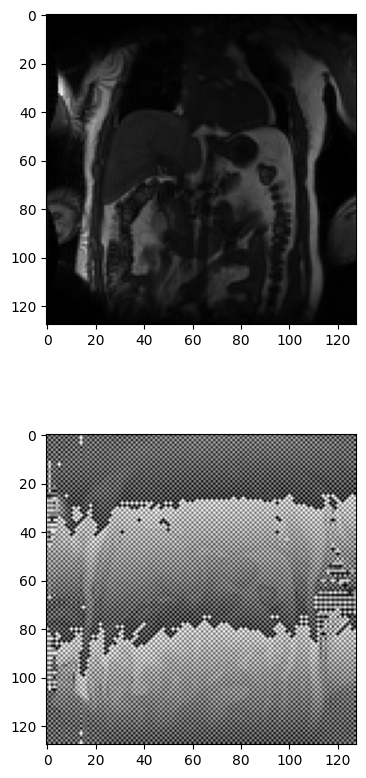

In [65]:
inphase_k = np.load(r'''/Users/harvey/Documents/Cambridge/Medical Imaging/MedIm_scripts/data/practical3/inphase.npy''')
outphase_k = np.load(r'''/Users/harvey/Documents/Cambridge/Medical Imaging/MedIm_scripts/data/practical3/outphase.npy''')

inphase_k[:128,:] = 0
inphase_k[:,:128] = 0
inphase_k[-128:,:] = 0
inphase_k[:,-128:] = 0

padded_k = inphase_k[192:320,192:320]
padded_im = np.fft.ifft2(padded_k)

plt.figure(figsize=(4,10))
plt.subplot(211)
plt.imshow(fliprot(np.abs(padded_im)), cmap='gray') #fat
plt.subplot(212)
plt.imshow(fliprot(np.angle(padded_im)), cmap='gray') #water

In [64]:
a = np.arange(1,10)
b = np.meshgrid(a,a,)[0]
print(a)
print(b)
b[:,-2:] = 0
b[-2:,:] = 0
print()
print(b)

[1 2 3 4 5 6 7 8 9]
[[1 2 3 4 5 6 7 8 9]
 [1 2 3 4 5 6 7 8 9]
 [1 2 3 4 5 6 7 8 9]
 [1 2 3 4 5 6 7 8 9]
 [1 2 3 4 5 6 7 8 9]
 [1 2 3 4 5 6 7 8 9]
 [1 2 3 4 5 6 7 8 9]
 [1 2 3 4 5 6 7 8 9]
 [1 2 3 4 5 6 7 8 9]]

[[1 2 3 4 5 6 7 0 0]
 [1 2 3 4 5 6 7 0 0]
 [1 2 3 4 5 6 7 0 0]
 [1 2 3 4 5 6 7 0 0]
 [1 2 3 4 5 6 7 0 0]
 [1 2 3 4 5 6 7 0 0]
 [1 2 3 4 5 6 7 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]]


#### Q6. 

Load "brain 1 npy", "brain2.npy" and "brain3.npy". Before displaying them, use numpy.rot90 on the images to put the frontal lobe at the top of the image. Use all three images and display an average image. What is the maximum value of each image?

Maximum value of brain 1 57531.164
Maximum value of brain 2 5697.704
Maximum value of brain 3 1962.6506
Maximum value of brain avg 19213.21


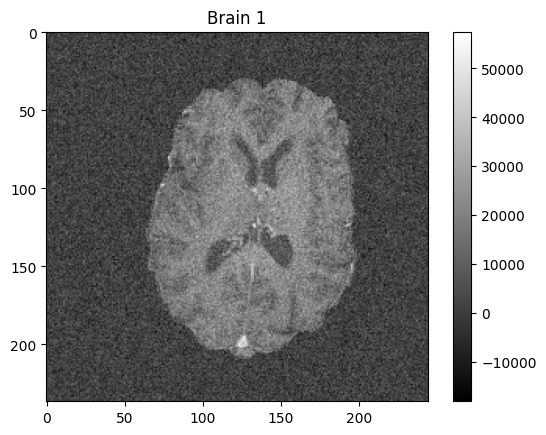

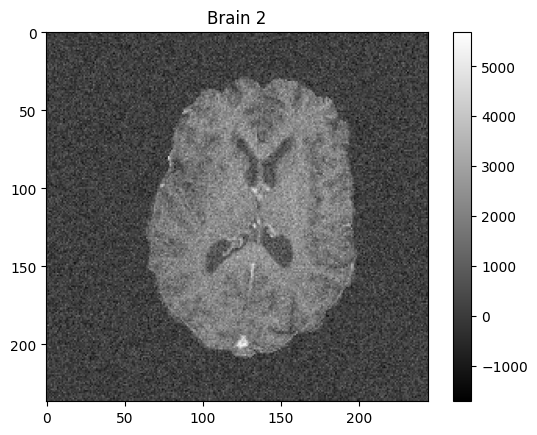

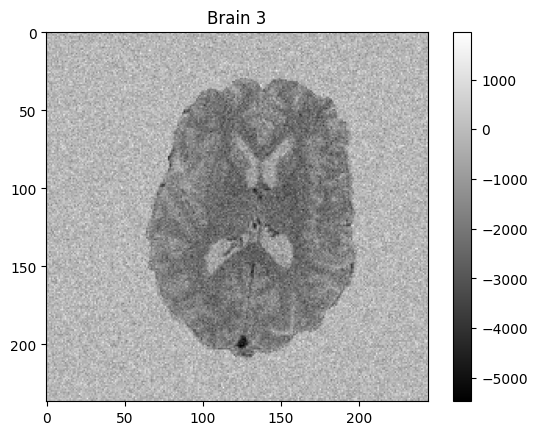

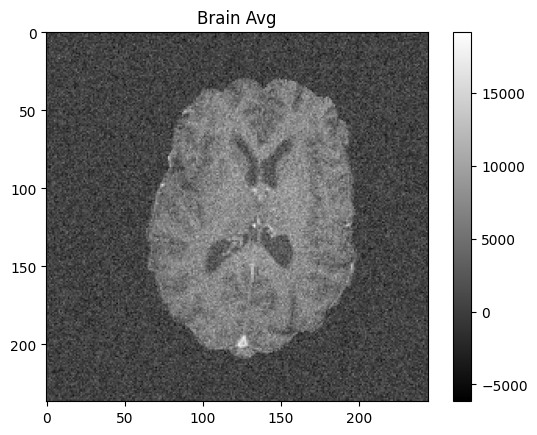

In [70]:
brain1 = np.load(r'''/Users/harvey/Documents/Cambridge/Medical Imaging/MedIm_scripts/data/practical3/brain_1.npy''')
brain2 = np.load(r'''/Users/harvey/Documents/Cambridge/Medical Imaging/MedIm_scripts/data/practical3/brain_2.npy''')
brain3 = np.load(r'''/Users/harvey/Documents/Cambridge/Medical Imaging/MedIm_scripts/data/practical3/brain_3.npy''')

brain1 = np.rot90(brain1)
brain2 = np.rot90(brain2)
brain3 = np.rot90(brain3)
brain_avg = (brain1 + brain2 + brain3)/3


plt.figure()
plt. imshow(brain1, cmap = 'gray')
plt.title('Brain 1')
plt.colorbar()
print('Maximum value of brain 1', np.max(brain1))

plt.figure()
plt. imshow(brain2, cmap = 'gray')
plt.title('Brain 2')
plt.colorbar()
print('Maximum value of brain 2', np.max(brain2))

plt.figure()
plt. imshow(brain3, cmap = 'gray')
plt.title('Brain 3')
plt.colorbar()
print('Maximum value of brain 3', np.max(brain3))

plt.figure()
plt. imshow(brain_avg, cmap = 'gray')
plt.title('Brain Avg')
plt.colorbar()
print('Maximum value of brain avg', np.max(brain_avg))

#### Q7. 

Calculate the standard deviation of the first 3 rows or columns of each brain image. Divide the brain image by its standard deviation of this region of noise. Display one brain image. What is the maximum value of each brain image?

Maximum value of brain 1 12.377719
Maximum value of brain 2 12.28402
Maximum value of brain 3 4.13056
Maximum value of brain avg 4.622392


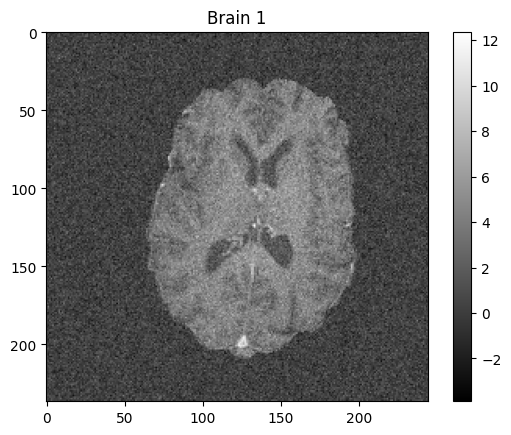

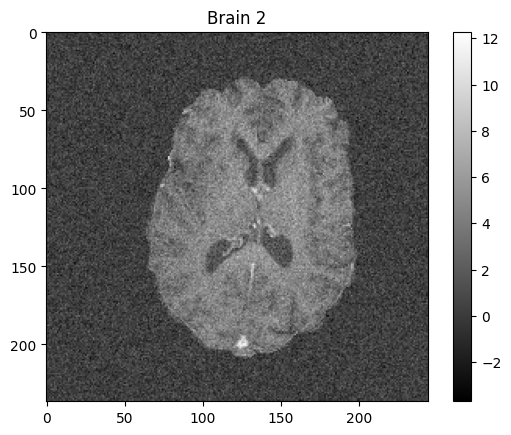

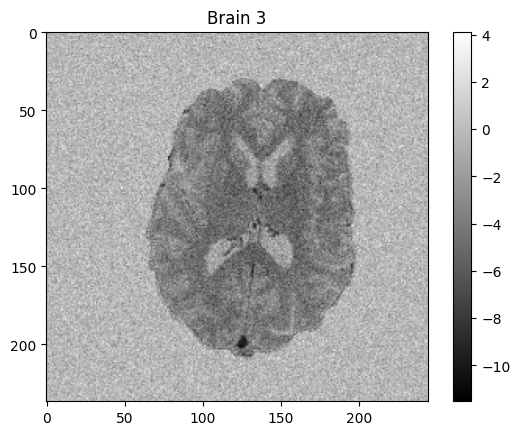

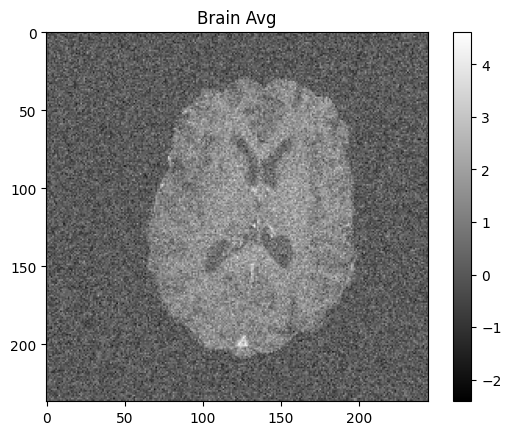

In [71]:
brain1 = np.load(r'''/Users/harvey/Documents/Cambridge/Medical Imaging/MedIm_scripts/data/practical3/brain_1.npy''')
brain2 = np.load(r'''/Users/harvey/Documents/Cambridge/Medical Imaging/MedIm_scripts/data/practical3/brain_2.npy''')
brain3 = np.load(r'''/Users/harvey/Documents/Cambridge/Medical Imaging/MedIm_scripts/data/practical3/brain_3.npy''')

brain1 = np.rot90(brain1)
brain2 = np.rot90(brain2)
brain3 = np.rot90(brain3)

brain1 = brain1 / np.std(brain1[:3])
brain2 = brain2 / np.std(brain2[:3])
brain3 = brain3 / np.std(brain3[:3])

brain_avg = (brain1 + brain2 + brain3)/3


plt.figure()
plt. imshow(brain1, cmap = 'gray')
plt.title('Brain 1')
plt.colorbar()
print('Maximum value of brain 1', np.max(brain1))

plt.figure()
plt. imshow(brain2, cmap = 'gray')
plt.title('Brain 2')
plt.colorbar()
print('Maximum value of brain 2', np.max(brain2))

plt.figure()
plt. imshow(brain3, cmap = 'gray')
plt.title('Brain 3')
plt.colorbar()
print('Maximum value of brain 3', np.max(brain3))

plt.figure()
plt. imshow(brain_avg, cmap = 'gray')
plt.title('Brain Avg')
plt.colorbar()
print('Maximum value of brain avg', np.max(brain_avg))

#### Q8. 
Combine the three images by calculating the root-sum-of-squares, and display. How does this compare with previous images?

Maximum value of brain sos 19.391033


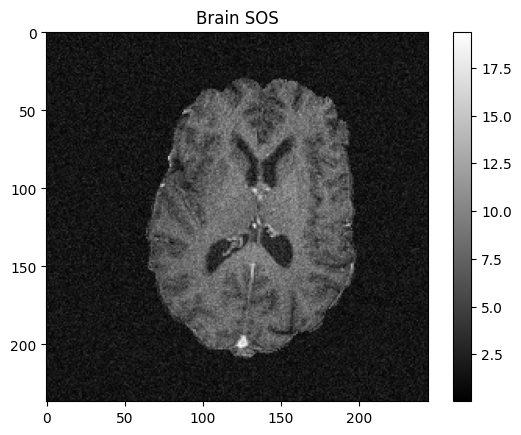

In [72]:
brain_sos = np.sqrt(brain1**2 + brain2**2 + brain3**2)

plt.figure()
plt. imshow(brain_sos, cmap = 'gray')
plt.title('Brain SOS')
plt.colorbar()
print('Maximum value of brain sos', np.max(brain_sos))

#### Q9. 

Perform median filtering on the brain1 image. Do this by first importing the function,
from scipy.ndimage import median_filter. This filter takes two inputs: the first is image, and the second is kernel size. Use a kernel size of 3, and display. How does this compare with the root-sum-of-squares image?

Maximum value of brain filtered 47145.07


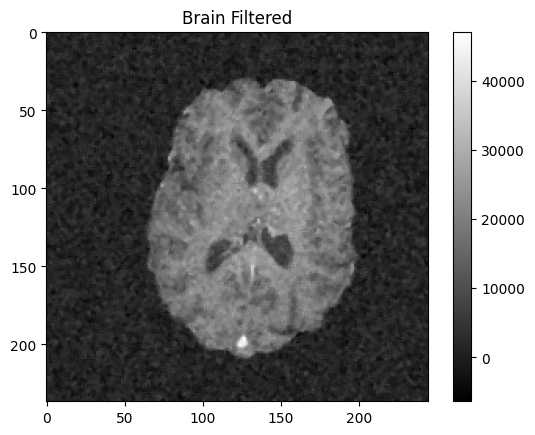

In [76]:
from scipy.ndimage import median_filter

brain1 = np.load(r'''/Users/harvey/Documents/Cambridge/Medical Imaging/MedIm_scripts/data/practical3/brain_1.npy''')
brain2 = np.load(r'''/Users/harvey/Documents/Cambridge/Medical Imaging/MedIm_scripts/data/practical3/brain_2.npy''')
brain3 = np.load(r'''/Users/harvey/Documents/Cambridge/Medical Imaging/MedIm_scripts/data/practical3/brain_3.npy''')
brain1 = np.rot90(brain1)
brain2 = np.rot90(brain2)
brain3 = np.rot90(brain3)

brain1_filtered = median_filter(brain1, 3)

plt.figure()
plt. imshow(brain1_filtered, cmap = 'gray')
plt.title('Brain Filtered')
plt.colorbar()
print('Maximum value of brain filtered', np.max(brain1_filtered))

#### Q10a. 

Use from skimage.metrics import mean_squared _error. This takes iwo images as inputs. What is the MSE between the median filtered brain, and the root-sum-of-squares (rSOS) image in previous two questions?

In [80]:
from skimage.metrics import mean_squared_error

brain_mse = mean_squared_error(brain1_filtered, brain_sos)

print(brain_mse)

126750224.6551779


In [81]:
print('hi')

hi
